In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
from copy import deepcopy

In [2]:
df = pd.read_csv("./data/stock-data.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    20 non-null     str  
 1   Close   20 non-null     int64
 2   Start   20 non-null     int64
 3   High    20 non-null     int64
 4   Low     20 non-null     int64
 5   Volume  20 non-null     int64
dtypes: int64(5), str(1)
memory usage: 1.1 KB


In [3]:
# 문자열을 Timestamp로 변환

df["new_Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Close,Start,High,Low,Volume,new_Date
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26


In [4]:
type(df["new_Date"])

pandas.Series

In [5]:
df = df.set_index("new_Date")
df = df.drop("Date", axis=1)

df.head()

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-07-02,10100,10850,10900,10000,137977
2018-06-29,10700,10550,10900,9990,170253
2018-06-28,10400,10900,10950,10150,155769
2018-06-27,10900,10800,11050,10500,133548
2018-06-26,10800,10900,11000,10700,63039


In [6]:
pd.DatetimeIndex(["2022-12-25", "2023/01/25"])

DatetimeIndex(['2022-12-25', '2023-01-25'], dtype='datetime64[us]', freq=None)

In [7]:
pd.Timestamp("2023-12-25")

Timestamp('2023-12-25 00:00:00')

In [8]:
pd.to_datetime("2023년 12월 25일", format="%Y년 %m월 %d일")

Timestamp('2023-12-25 00:00:00')

In [9]:
pd.to_datetime("12-12-2023 23:59:59", format="%d-%m-%Y %H:%M:%S")

Timestamp('2023-12-12 23:59:59')

In [10]:
pr_m = pd.period_range(start="2024-01-01", end=None, periods=3,  freq="M")

print(pr_m)

PeriodIndex(['2024-01', '2024-02', '2024-03'], dtype='period[M]')


In [11]:
pr_h = pd.period_range(start="2024-01-01", end=None, periods=3,  freq="h")

print(pr_h)

PeriodIndex(['2024-01-01 00:00', '2024-01-01 01:00', '2024-01-01 02:00'], dtype='period[h]')


In [12]:
pr_2h = pd.period_range(start="2024-01-01", end=None, periods=3,  freq="2D")

print(pr_2h)

PeriodIndex(['2024-01-01', '2024-01-03', '2024-01-05'], dtype='period[2D]')


In [13]:
# 시계열 데이터 활용

df = pd.read_csv("./data/stock-data.csv")

df["new_Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Close,Start,High,Low,Volume,new_Date
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26


In [14]:
df["Year"] = df["new_Date"].dt.year
df["Monthj"] = df["new_Date"].dt.month
df["Day"] = df["new_Date"].dt.day
df.head()

,Date,Close,Start,High,Low,Volume,new_Date,Year,Monthj,Day
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02,2018,7,2
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26


In [15]:
df["Date_yr"] = df["new_Date"].dt.to_period(freq="Y")
df["Date_m"] = df["new_Date"].dt.to_period(freq="M")

df.head()

,Date,Close,Start,High,Low,Volume,new_Date,Year,Monthj,Day,Date_yr,Date_m
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02,2018,7,2,2018,2018-07
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06


In [16]:
# 날짜 데이터 분리

df_june = df[df["Date_m"].astype(str).str.fullmatch("2018-06")]
df_june.head()

,Date,Close,Start,High,Low,Volume,new_Date,Year,Monthj,Day,Date_yr,Date_m
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06
5,2018-06-25,11150,11400,11450,11000,55519,2018-06-25,2018,6,25,2018,2018-06


In [17]:
# 날짜 데이터 분리 2

cond = df["Date_m"] == pd.Period("2018-06")
df[cond]

,Date,Close,Start,High,Low,Volume,new_Date,Year,Monthj,Day,Date_yr,Date_m
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06
5,2018-06-25,11150,11400,11450,11000,55519,2018-06-25,2018,6,25,2018,2018-06
6,2018-06-22,11300,11250,11450,10750,134805,2018-06-22,2018,6,22,2018,2018-06
7,2018-06-21,11200,11350,11750,11200,133002,2018-06-21,2018,6,21,2018,2018-06
8,2018-06-20,11550,11200,11600,10900,308596,2018-06-20,2018,6,20,2018,2018-06
9,2018-06-19,11300,11850,11950,11300,180656,2018-06-19,2018,6,19,2018,2018-06
10,2018-06-18,12000,13400,13400,12000,309787,2018-06-18,2018,6,18,2018,2018-06


In [18]:
df_june = df_june.set_index("new_Date")

In [19]:
df_june

,Date,Close,Start,High,Low,Volume,Year,Monthj,Day,Date_yr,Date_m
new_Date,,,,,,,,,,,
2018-06-29,2018-06-29,10700,10550,10900,9990,170253,2018,6,29,2018,2018-06
2018-06-28,2018-06-28,10400,10900,10950,10150,155769,2018,6,28,2018,2018-06
2018-06-27,2018-06-27,10900,10800,11050,10500,133548,2018,6,27,2018,2018-06
2018-06-26,2018-06-26,10800,10900,11000,10700,63039,2018,6,26,2018,2018-06
2018-06-25,2018-06-25,11150,11400,11450,11000,55519,2018,6,25,2018,2018-06
2018-06-22,2018-06-22,11300,11250,11450,10750,134805,2018,6,22,2018,2018-06
2018-06-21,2018-06-21,11200,11350,11750,11200,133002,2018,6,21,2018,2018-06
2018-06-20,2018-06-20,11550,11200,11600,10900,308596,2018,6,20,2018,2018-06
2018-06-19,2018-06-19,11300,11850,11950,11300,180656,2018,6,19,2018,2018-06


In [20]:
# 시간 인덱스 활용

df = pd.read_csv("./data/stock-data.csv")

df["new_Date"] = pd.to_datetime(df["Date"])

df = df.set_index("new_Date").sort_index()
df

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-06-01,2018-06-01,11900,11800,12100,11750,32062
2018-06-04,2018-06-04,11900,11900,12200,11700,25171
2018-06-05,2018-06-05,12150,11800,12250,11800,42485
2018-06-07,2018-06-07,11950,12200,12300,11900,49088
2018-06-08,2018-06-08,11950,11950,12200,11800,59258
2018-06-11,2018-06-11,11950,12000,12250,11950,62293
2018-06-12,2018-06-12,13200,12200,13300,12050,558148
2018-06-14,2018-06-14,13450,13200,13700,13150,347451
2018-06-15,2018-06-15,13400,13600,13600,12900,201376


In [21]:
df.loc["2018-06-27"]

Date      2018-06-27
Close          10900
Start          10800
High           11050
Low            10500
Volume        133548
Name: 2018-06-27 00:00:00, dtype: object

In [22]:
df.loc["2018-07"]

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-07-02,2018-07-02,10100,10850,10900,10000,137977


In [23]:
df.loc["2018-06-27":"2018-07-02"]

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-06-27,2018-06-27,10900,10800,11050,10500,133548
2018-06-28,2018-06-28,10400,10900,10950,10150,155769
2018-06-29,2018-06-29,10700,10550,10900,9990,170253
2018-07-02,2018-07-02,10100,10850,10900,10000,137977


In [24]:
df[(df.index < "2018-06-05")]

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-06-01,2018-06-01,11900,11800,12100,11750,32062
2018-06-04,2018-06-04,11900,11900,12200,11700,25171


In [25]:
df.loc[pd.Timestamp(2018, 6, 27):pd.Timestamp(2018, 7, 2)]

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-06-27,2018-06-27,10900,10800,11050,10500,133548
2018-06-28,2018-06-28,10400,10900,10950,10150,155769
2018-06-29,2018-06-29,10700,10550,10900,9990,170253
2018-07-02,2018-07-02,10100,10850,10900,10000,137977


In [26]:
df.loc[pd.Timestamp(2018, 6, 27, 10, 30, 0):pd.Timestamp(2018, 7, 2, 23, 59, 59)]

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-06-28,2018-06-28,10400,10900,10950,10150,155769
2018-06-29,2018-06-29,10700,10550,10900,9990,170253
2018-07-02,2018-07-02,10100,10850,10900,10000,137977


In [27]:
# 날짜, 시간의 절대적 차이 1
print(pd.Timedelta("1 days"))
print(pd.Timedelta(days=1))
print(pd.Timedelta("1 days 1 hours 1minutes 1 seconds"))
print(pd.Timedelta(days=1, hours=1, minutes=1, seconds=1))

1 days 00:00:00
1 days 00:00:00
1 days 01:01:01
1 days 01:01:01


In [28]:
pd.to_timedelta(["1 days", "3 hours"])

TimedeltaIndex(['1 days 00:00:00', '0 days 03:00:00'], dtype='timedelta64[us]', freq=None)

In [30]:
a = df.index
print(a)

DatetimeIndex(['2018-06-01', '2018-06-04', '2018-06-05', '2018-06-07',
               '2018-06-08', '2018-06-11', '2018-06-12', '2018-06-14',
               '2018-06-15', '2018-06-18', '2018-06-19', '2018-06-20',
               '2018-06-21', '2018-06-22', '2018-06-25', '2018-06-26',
               '2018-06-27', '2018-06-28', '2018-06-29', '2018-07-02'],
              dtype='datetime64[us]', name='new_Date', freq=None)


In [31]:
b = pd.Timestamp("2018-07-03") - a
print(b)

TimedeltaIndex(['32 days', '29 days', '28 days', '26 days', '25 days',
                '22 days', '21 days', '19 days', '18 days', '15 days',
                '14 days', '13 days', '12 days', '11 days',  '8 days',
                 '7 days',  '6 days',  '5 days',  '4 days',  '1 days'],
               dtype='timedelta64[us]', name='new_Date', freq=None)


In [32]:
c = a - pd.Timedelta(days=1)
print(c)

DatetimeIndex(['2018-05-31', '2018-06-03', '2018-06-04', '2018-06-06',
               '2018-06-07', '2018-06-10', '2018-06-11', '2018-06-13',
               '2018-06-14', '2018-06-17', '2018-06-18', '2018-06-19',
               '2018-06-20', '2018-06-21', '2018-06-24', '2018-06-25',
               '2018-06-26', '2018-06-27', '2018-06-28', '2018-07-01'],
              dtype='datetime64[us]', name='new_Date', freq=None)


In [ ]:
# 시계열 변환
df = pd.read_csv("./data/stock-data.csv")
df.head()

,Date,Close,Start,High,Low,Volume
0,2018-07-02,10100,10850,10900,10000,137977
1,2018-06-29,10700,10550,10900,9990,170253
2,2018-06-28,10400,10900,10950,10150,155769
3,2018-06-27,10900,10800,11050,10500,133548
4,2018-06-26,10800,10900,11000,10700,63039


In [35]:
df["new_Date"] = pd.to_datetime(df["Date"])
df = df.drop(columns=["Date"])

In [36]:
df = df.set_index("new_Date").sort_index()

ts = df.head(10)
ts

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900,11800,12100,11750,32062
2018-06-04,11900,11900,12200,11700,25171
2018-06-05,12150,11800,12250,11800,42485
2018-06-07,11950,12200,12300,11900,49088
2018-06-08,11950,11950,12200,11800,59258
2018-06-11,11950,12000,12250,11950,62293
2018-06-12,13200,12200,13300,12050,558148
2018-06-14,13450,13200,13700,13150,347451
2018-06-15,13400,13600,13600,12900,201376


In [37]:
ts.shift(1)

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,NaN,NaN,NaN,NaN,NaN
2018-06-04,11900.0,11800.0,12100.0,11750.0,32062.0
2018-06-05,11900.0,11900.0,12200.0,11700.0,25171.0
2018-06-07,12150.0,11800.0,12250.0,11800.0,42485.0
2018-06-08,11950.0,12200.0,12300.0,11900.0,49088.0
2018-06-11,11950.0,11950.0,12200.0,11800.0,59258.0
2018-06-12,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-14,13200.0,12200.0,13300.0,12050.0,558148.0
2018-06-15,13450.0,13200.0,13700.0,13150.0,347451.0


In [38]:
ts.shift(-2)

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,12150.0,11800.0,12250.0,11800.0,42485.0
2018-06-04,11950.0,12200.0,12300.0,11900.0,49088.0
2018-06-05,11950.0,11950.0,12200.0,11800.0,59258.0
2018-06-07,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-08,13200.0,12200.0,13300.0,12050.0,558148.0
2018-06-11,13450.0,13200.0,13700.0,13150.0,347451.0
2018-06-12,13400.0,13600.0,13600.0,12900.0,201376.0
2018-06-14,12000.0,13400.0,13400.0,12000.0,309787.0
2018-06-15,NaN,NaN,NaN,NaN,NaN


In [39]:
ts.shift(3, freq="D")

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-04,11900,11800,12100,11750,32062
2018-06-07,11900,11900,12200,11700,25171
2018-06-08,12150,11800,12250,11800,42485
2018-06-10,11950,12200,12300,11900,49088
2018-06-11,11950,11950,12200,11800,59258
2018-06-14,11950,12000,12250,11950,62293
2018-06-15,13200,12200,13300,12050,558148
2018-06-17,13450,13200,13700,13150,347451
2018-06-18,13400,13600,13600,12900,201376


In [40]:
ts.asfreq("5D")

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900.0,11800.0,12100.0,11750.0,32062.0
2018-06-06,NaN,NaN,NaN,NaN,NaN
2018-06-11,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-16,NaN,NaN,NaN,NaN,NaN


In [41]:
ts.asfreq("5D", method="bfill")

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900,11800,12100,11750,32062
2018-06-06,11950,12200,12300,11900,49088
2018-06-11,11950,12000,12250,11950,62293
2018-06-16,12000,13400,13400,12000,309787


In [44]:
# 시계열 데이터 시각화

df = pd.read_csv("./data/stock-data.csv")
df["new_Date"] = pd.to_datetime(df["Date"])
df = df.drop(columns=["Date"])

df = df.set_index("new_Date").sort_index()

df.head()

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900,11800,12100,11750,32062
2018-06-04,11900,11900,12200,11700,25171
2018-06-05,12150,11800,12250,11800,42485
2018-06-07,11950,12200,12300,11900,49088
2018-06-08,11950,11950,12200,11800,59258


<Axes: xlabel='new_Date'>

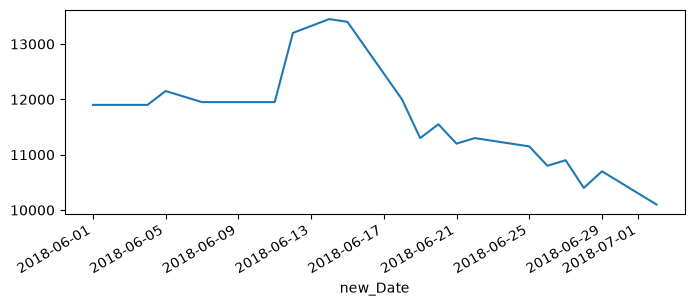

In [45]:
df["Close"].plot(figsize=(8, 3))

<Axes: xlabel='new_Date'>

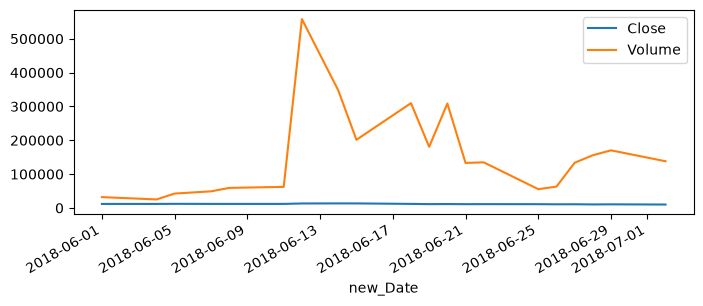

In [47]:
df[["Close", "Volume"]].plot(figsize=(8, 3))

<Axes: >

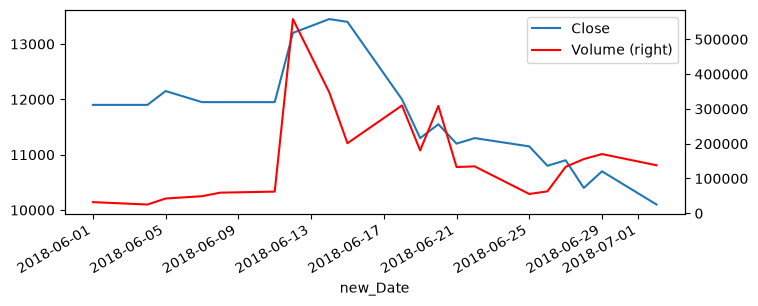

In [49]:
df["Close"].plot(label="Close", legend=True, figsize=(8, 3))
df["Volume"].plot(secondary_y=True, style="r", label="Volume", legend=True)

<Axes: xlabel='new_Date'>

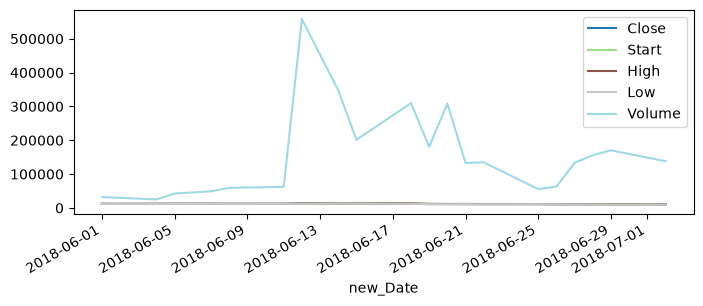

In [50]:
df.plot(figsize=(8, 3), colormap="tab20")

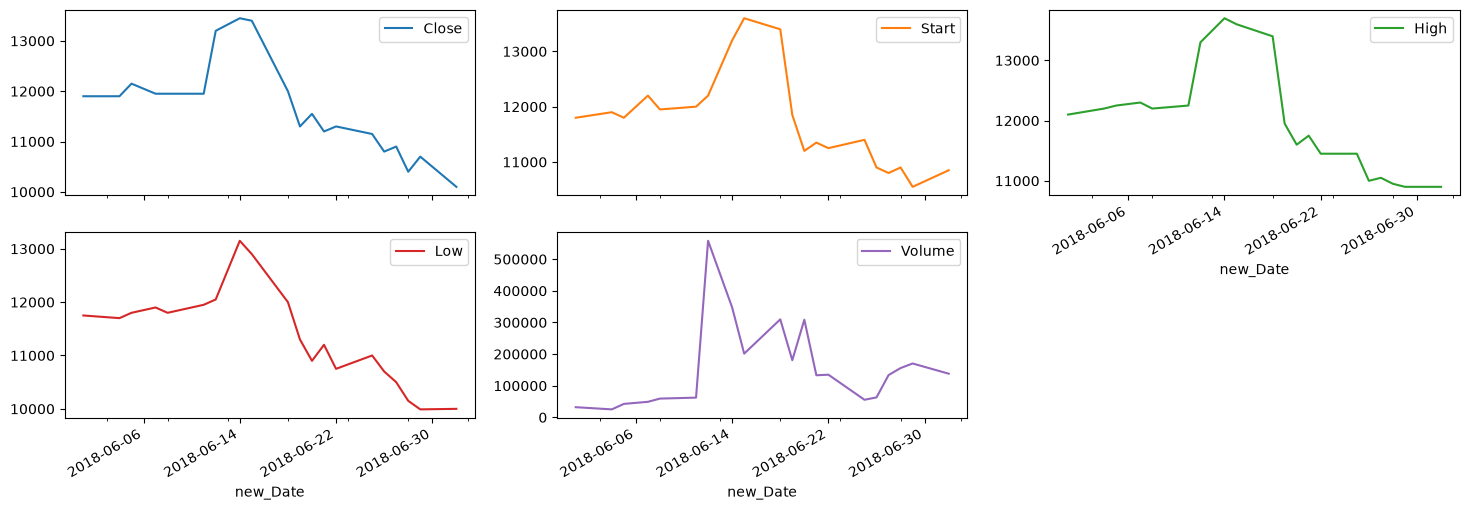

In [51]:
axes = df.plot(subplots=True, layout=(2, 3), figsize=(18, 6), sharex=True, sharey=False)

axes[0,0].xaxis.set_major_locator(plt.MaxNLocator(5))

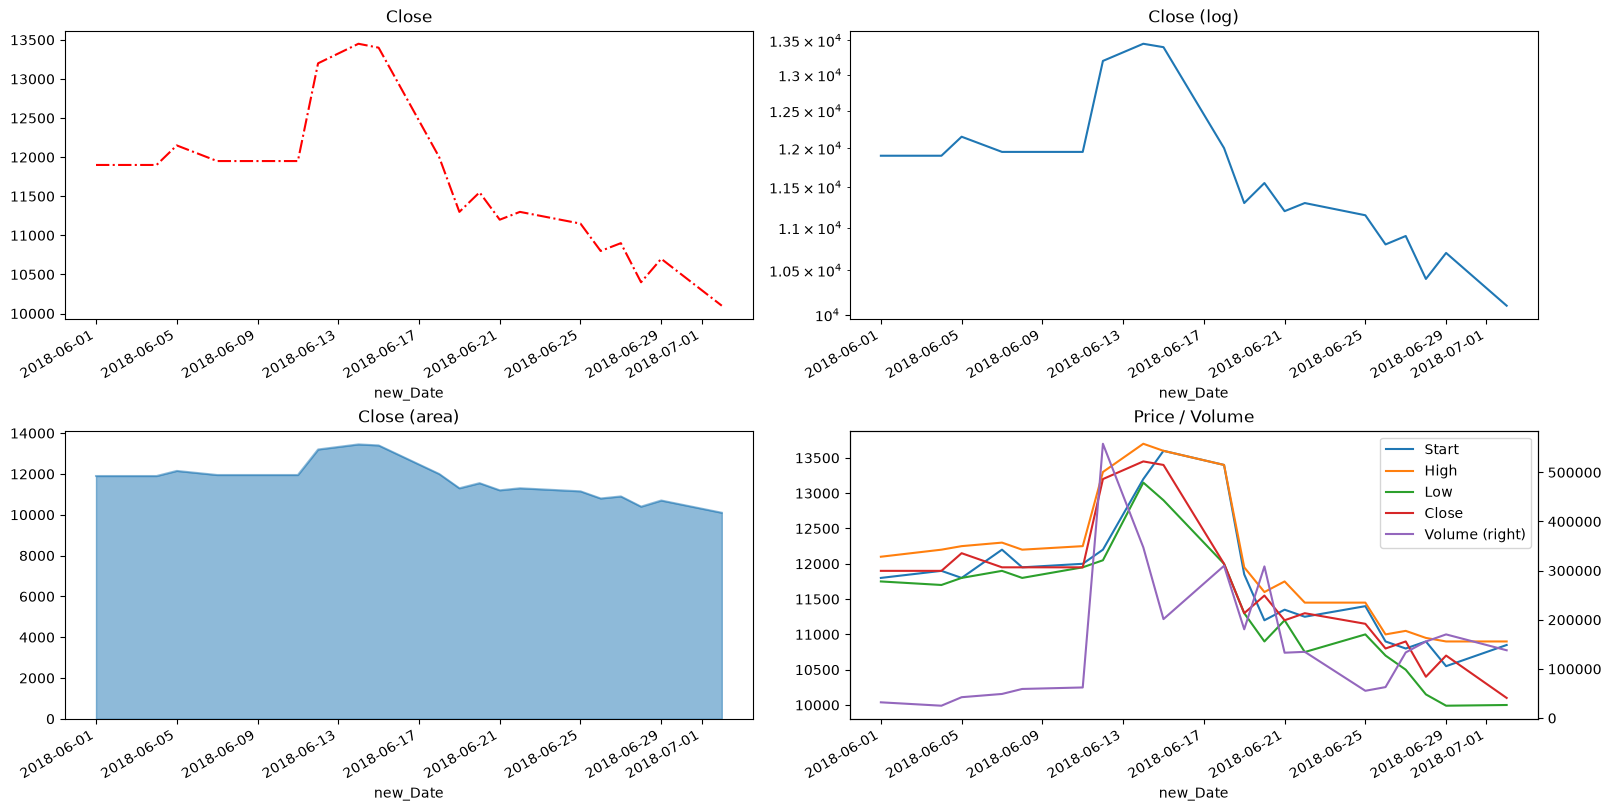

In [55]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 8), constrained_layout=True)

# 선 스타일
df["Close"].plot(ax=axes[0, 0], style="r-.")
axes[0, 0].set_title("Close")

# 로그 스케일 변환
df["Close"].plot(ax=axes[0, 1], logy=True)
axes[0, 1].set_title("Close (log)")

# 면적 그래프
df["Close"].plot(ax=axes[1, 0], kind="area", alpha=0.5)
axes[1, 0].set_title("Close (area)")

# 보조 축 적용
df[["Start", "High", "Low", "Close"]].plot(ax=axes[1, 1], legend=True)
df["Volume"].plot(ax=axes[1, 1], legend=True, secondary_y=True)
axes[1, 1].set_title("Price / Volume")

plt.show()

In [58]:
my_key = "dpd-80bc42f5-89e5813533cd59c2a119bb05bdf7186d87a1b5f9ebdb8a9a511c654248fb0a0d"

# 특정 종목(stockCode)의 재무항목(indicatorName) 데이터를 가져오는 함수를 정의
def get_financials(stockCode, indicatorName, apiKey, consolidated=True, ttm=True):
    if consolidated:
        if ttm:
            url = f"https://api.dapada.io/company/getConsolidatedFinancialDataByTTM?indicatorName={indicatorName}&stockCode={stockCode}"
        
        else:
            url = f"https://api.dapada.io/company/getConsolidatedFinancialDataByCUR?indicatorName={indicatorName}&stockCode={stockCode}"

    else:
        if ttm:
            url = f"https://api.dapada.io/company/getSeparatedFinancialDataByTTM?indicatorName={indicatorName}&stockCode={stockCode}" 
        
        else:
            url = f"https://api.dapada.io/company/getSeparatedFinancialDataByCUR?indicatorName={indicatorName}&stockCode={stockCode}"

    headers = {
        "Authorization": f"{apiKey}"
    }
    response = requests.get(url, headers=headers)
    result = response.json()

    return pd.DataFrame(result)

In [61]:
df_samsung = get_financials(stockCode="005930", indicatorName="영업이익", apiKey=my_key, consolidated=True, ttm=False)

df_samsung["change"] = df_samsung["value"].pct_change()
df_samsung = df_samsung.set_index("quarter")

df_samsung

,value,change
quarter,,
2023-Q3,2433534000000,NaN
2023-Q2,668547000000,-0.725277
2023-Q1,640178000000,-0.042434
2022-Q4,4306131000000,5.726459
2022-Q3,9389198000000,1.180426
2022-Q2,11098805000000,0.182082
2022-Q1,11324628000000,0.020347


In [63]:
df_skhynix = get_financials(stockCode="000660", indicatorName="영업이익", apiKey=my_key, consolidated=True, ttm=False)

df_skhynix["change"] = df_skhynix["value"].pct_change()
df_skhynix = df_skhynix.set_index("quarter")

df_skhynix

,value,change
quarter,,
2023-Q3,-1791961000000,NaN
2023-Q2,-2882084000000,0.608341
2023-Q1,-3402302000000,0.180501
2022-Q4,-1898374000000,-0.442032
2022-Q3,1655559000000,-1.872093
2022-Q2,4192617000000,1.532448
2022-Q1,2859615000000,-0.317940


In [66]:
df_samsung.style.format(precision=2, thousands=",", decimal=".")

,value,change
quarter,,
2023-Q3,"2,433,534,000,000",nan
2023-Q2,"668,547,000,000",-0.73
2023-Q1,"640,178,000,000",-0.04
2022-Q4,"4,306,131,000,000",5.73
2022-Q3,"9,389,198,000,000",1.18
2022-Q2,"11,098,805,000,000",0.18
2022-Q1,"11,324,628,000,000",0.02
